<b><h1><span style="color:thistle">Corelation Matrixes</h1>

<b>Task: Slice up time spectra by making corelation matrices using numpy class

1) Load data with montage, info etc.

    >Preload probably false

2) Butter your way to signal frequency of 1 - 45[Hz]

3) Downsample the signal for your <span style="color:thistle"> "Fuň Fuň FRrRrrRRRrRrrrrRrr" </span> laptop form 8000Hz to 250hz or something
    >Scippz signal decimate ?

    >target 250hz, q=int(8000/250), ftype='fir', axis=1

4) For every 10 seconds in all timeline create corr matric:

   >Matrix in numpy is kinda <span style="color:red"> deprecated </span> but I can still use it probably or make my own <span style="color:red"> OR </span> use ordinary numpy class

5) Count correlation for every channel 

   >numpy.corr? (correlate)

7) Save matrix or load them to memory

   >.npy -> np.load_data

8) Plot it!
   
<div style="text-align: right;"><i> Jesus take the wheel...Take it from my hand</div>
<div style="text-align: right;"><i> -Manka 2026</div>

<h2>Imports and Styling</h2>

In [1]:
import numpy as np
import mne
import os
from elephant.signal_processing import butter
from scipy.signal import decimate
import matplotlib.pyplot as plt
import warnings as w

line = "\n❀----------------------------------------------------------❀\n"

<h2>Loading data, setting montage</h2>

In [2]:
path = "./../bigData/C01/ica/C01_2024-11-16_10-44-51_RS_before_ica.fif"
with w.catch_warnings():
    w.simplefilter("ignore", RuntimeWarning)
    ica = mne.io.read_raw_fif(path, preload=False)
print(line)
ica.set_montage(mne.channels.make_standard_montage("standard_1005"))

Opening raw data file ./../bigData/C01/ica/C01_2024-11-16_10-44-51_RS_before_ica.fif...
    Range : 0 ... 4287999 =      0.000 ...   536.000 secs
Ready.
Opening raw data file /home/manka/EEG/BoredEEG/Notebook/../bigData/C01/ica/C01_2024-11-16_10-44-51_RS_before_ica-1.fif...
    Range : 4288000 ... 4807672 =    536.000 ...   600.959 secs
Ready.

❀----------------------------------------------------------❀



<Raw | C01_2024-11-16_10-44-51_RS_before_ica.fif, 125 x 4807673 (601.0 s), ~152 KiB, data not loaded>

<h2>Directory</h2>

Where are we gonna save the matrices

In [3]:
out_dir = "corr_matrices"
os.makedirs(out_dir, exist_ok=True)

<h2>Band-pass filter (1–45 Hz)</h2>

Buttering or mne? thats the question... I would say lets do Butter first if I fail, then I try other solution

```Python
quart_ica = butter(
    ica.get_data(),
    highpass_frequency=0,
    lowpass_frequency=45
)
```
<i><b><span style="color:red">And this is Ladies & Gentlemans where this approach ENDS

<h1><span style="color:black">New approach</h1>

<b>Because applying filter on all data is RAM hungry (loading to memory), I need to take time snipplets first:

1) make cycle for 10s snipplets from data: <span style="color:lightsteelblue"><b>S</span></b>
   >apply filter on <span style="color:lightsteelblue"><b>S</span></b> BUT beware of the edge artifact
   >
   >downscale the <span style="color:lightsteelblue"><b>S</span></b>
   >
   >create matrix for <span style="color:lightsteelblue"><b>S</span></b>
   >
   >calculate matrix
   >
   >save matric
   >
   ><span style="color:darkseagreen"><b>repete</span></b>

<h3><b><span style="color:darkseagreen">Anti-allias Filter:</h3>

According to the Nyquist sampling theorem, the sampling rate should be at least twice the maximum frequency component of the signal of interest. In other words, the maximum frequency of the input signal should be less than or equal to half of the sampling rate.

Before sampling down 

<h3><b><span style="color:peachpuff">Filter Edge Artifact</h3>

Common consequence of snipplets. Digital filter cannot compute output at time T with only using sample T. It needs something around. Like in my zero phase filter "sosfiltfilt". At the start and end of the snipplets the filter has no real data so it invents the data by reflection, padding and zero extension and that leads to distortion around the edges. With my 10s windows with filter it's confined to 200-500ms at the edge. AKA Padlen is at least 15 samples in sosfiltfilt
```Python
pad = int(1 * sampling_freq)  # 1s

snipplet = ica.get_data(
    start=max(0, t_zero - pad),
    stop=min(len_ele, t_zero + len_signal + pad)
)

# filter

snipplet = snipplet[:, pad:-pad]
```

<h3><b><span style="color:lightsteelblue">Sampling down Decimate:</h3>

After anti-a filter. Mne does have it's own filter with resample, but [1] timing jitters can occur (NOT RELATED) and have some padding.

With MNE: 

```Python
ica.resample( sfreq=250, npad=auto)
```

<b>scipy.signal.decimate</b>

How the hell q, ftype and axis works ?

[1]<i>: You actually need to not be an idiot and build the imports for the inline documentation to work...

<h3><b><span style="color:rosybrown">Matrix creation</h3>

initialize empty matrix using np.ndarray using it's constructor. Also I am gonna count the permutation list using permutation(combination control)

```Python
np.array([[],[],[]])
```

<h3><b><span style="color:silver">Correlation</h3>

My first approach: Initialise matrix, calculate all the combination, then calculate corelation between combination. Thats extremly slow because of the big initialisation and then counting corr between every one of them...

Better appreach: Use vectorised math like 

```Python
corr_matrix = np.corrcoef(data)
``` 
which calculates result in one go or partial function for calcutation (dot one).

```Python 
# Normalize manually for them channels to be comparable 
data -= data.mean(axis=1, keepdims=True) #Substract mean (every channel gets one) from every data point, axis over time: SHAPE 
data /= data.std(axis=1, keepdims=True) #Standard deviation normalization. MEAN = 0, STD = 1

# Correlation = normalized dot product
corr = np.dot(data, data.T) / (data.shape[1] - 1) #Cosine of angle between two normalized channels = Pearson Correlation and deviation by N-1 where N = nchan.
```


In [45]:
out_dir = "corr_matrices"
os.makedirs(out_dir, exist_ok=True)

#frequncy
s_freq = int(ica.info['sfreq'])
new_freq = 250

len_snipp = 10 #len of snipplet

#samples size
n_samples = ica.n_times
window_samples = int(len_snipp*s_freq)

t_zero = 0
maximal = 0
while(t_zero+window_samples <= n_samples): #Make cycle over 10s in 1 sec jump
    snipplet = ica.get_data(#create snipplets
        start=t_zero, 
        stop=(t_zero+window_samples)
    )
    print(t_zero, t_zero+window_samples)
    """
    Butter your way to 1–45 Hz 
    """
    quatro_s = butter( 
        snipplet,
        highpass_frequency=1,
        lowpass_frequency=45,
        filter_function='sosfiltfilt',
        sampling_frequency=s_freq, 
        axis=1, order=6
    )
    print(quatro_s.shape)
    """
    Downsample (8000 -> 250 Hz)
    """
    down_quatro_s = decimate(
        quatro_s,
        q = int(s_freq/new_freq),
        ftype='fir',
        axis=1,
        zero_phase=True #to prevent phase shift:: 
    )
    print(down_quatro_s.shape)
    #break
    
    """
    Correlation Matrix
    """
    matrix = np.corrcoef(down_quatro_s)
    print(matrix)
    
    """
    Save Matrix
    """
    np.save(
        os.path.join(out_dir, f"corr_{int(t_zero // s_freq):04d}.npy"),
        matrix
    )
    
    t_zero += s_freq
    
    if(maximal == 10):
        break 
    maximal = maximal +1
    print( line)
    

print("cca 15minutes")

0 80000
(125, 80000)
(125, 2500)
[[ 1.          0.51540967  0.8091195  ... -0.41128395 -0.29875158
   0.05801368]
 [ 0.51540967  1.          0.57166977 ... -0.33639984 -0.20972611
  -0.02126391]
 [ 0.8091195   0.57166977  1.         ... -0.53157922 -0.32848611
   0.02174488]
 ...
 [-0.41128395 -0.33639984 -0.53157922 ...  1.          0.57379011
  -0.00542131]
 [-0.29875158 -0.20972611 -0.32848611 ...  0.57379011  1.
   0.02571814]
 [ 0.05801368 -0.02126391  0.02174488 ... -0.00542131  0.02571814
   1.        ]]

❀----------------------------------------------------------❀

8000 88000
(125, 80000)
(125, 2500)
[[ 1.00000000e+00  4.94587486e-01  8.18307851e-01 ... -4.69456643e-01
  -3.03444242e-01  4.96108775e-02]
 [ 4.94587486e-01  1.00000000e+00  5.45490564e-01 ... -3.11442189e-01
  -2.03291044e-01 -3.68679767e-02]
 [ 8.18307851e-01  5.45490564e-01  1.00000000e+00 ... -5.46647979e-01
  -3.57635081e-01  8.20903716e-04]
 ...
 [-4.69456643e-01 -3.11442189e-01 -5.46647979e-01 ...  1.0000000

<h2>No sexism for PC's</h2>

Because I can use cluster or new PC in the future I took code working on smaller snipplet and gave it the biggest snipplet of them all: INPUT data

In [10]:
#frequency
s_freq = int(ica.info['sfreq'])#8000
new_freq = 250

len_snipp = 10 #len of snipplet
"""
PRE
"""
down_quatro_s = decimate(
    butter(
        ica.get_data(ica,
                    start = 0, 
                    stop = len_snipp*s_freq),
        highpass_frequency=1,
        lowpass_frequency=45,
        filter_function='sosfiltfilt',
        sampling_frequency=s_freq
        ),
    q = int(s_freq/new_freq),
    ftype='fir',
    axis=1,
    zero_phase=True
)
window_samples = int(len_snipp*new_freq)

# /
# t_zero = 0
# maxmal = 0
# while(t_zero+window_samples <= down_quatro_s.shape[1]): #Make cycle over 10s in 1 sec jump
#     snipplet = down_quatro_s[:,t_zero:t_zero+window_samples]
#     """
#     Correlation Matrix
#     """
#     matrix = np.corrcoef(snipplet)
#     #print(matrix,"\n", matrix.shape, line)
    
#     """
#     Save Matrix
#     """
#     np.save(
#         os.path.join(out_dir, f"corr_{int(t_zero // new_freq):04d}.npy"),
#         matrix
#     )
#     t_zero = t_zero+new_freq


KeyboardInterrupt: 

In [11]:
plt.figure(figsize=(10,3))
plt.plot(down_quatro_s)

NameError: name 'down_quatro_s' is not defined

<Figure size 1000x300 with 0 Axes>

<h2>Plotting it's demise...</h2>

(125, 80000)
(125, 80000)
(125, 2500)


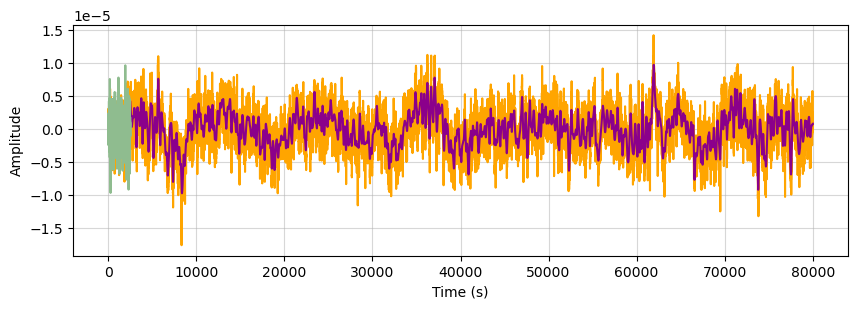

In [5]:
plt.figure(figsize=(10,3))
plt.plot(snipplet[0], color='orange', label="Snipplet of 10s")
plt.plot(quatro_s[0], color='darkmagenta', label="Filter 1-45Hz")
plt.plot(down_quatro_s[0], color='darkseagreen', label="Downsample 8000 -> 250")
plt.grid(alpha=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')



In [9]:
plt.plot(down_quatro_s[0], color='darkseagreen', label="Downsample 8000 -> 250")

NameError: name 'down_quatro_s' is not defined

<h2>Plotting demise final</h2>

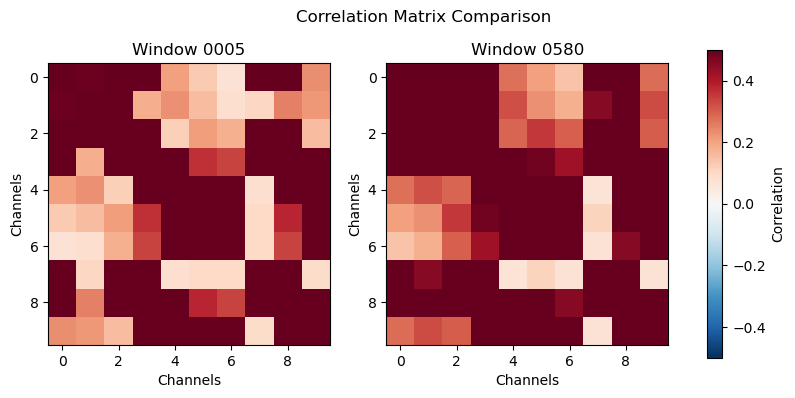


❀----------------------------------------------------------❀



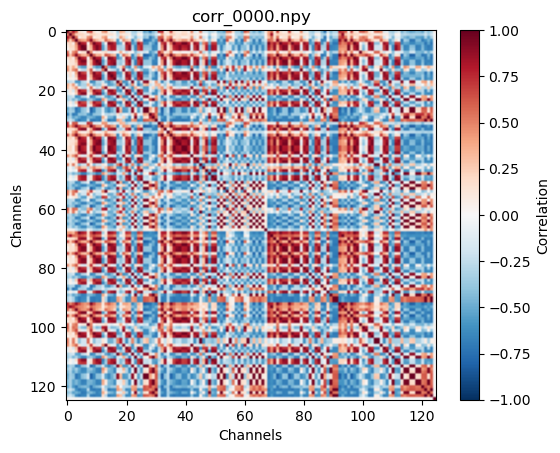

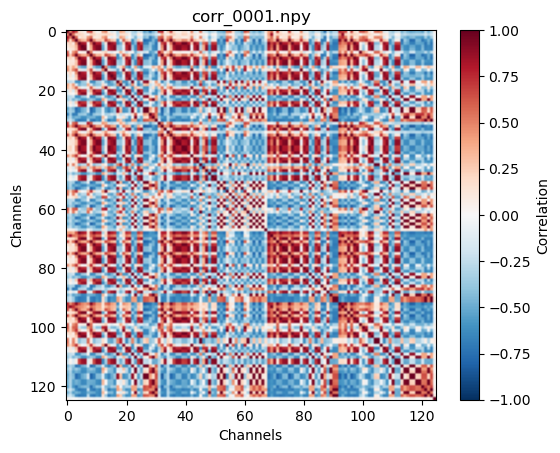

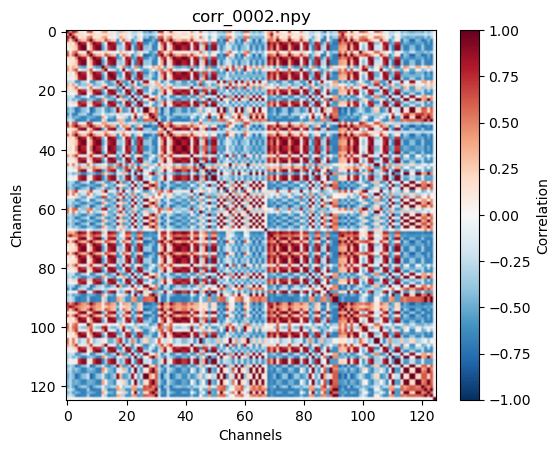

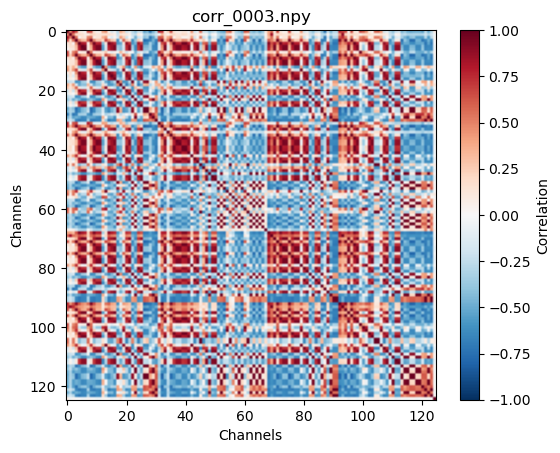

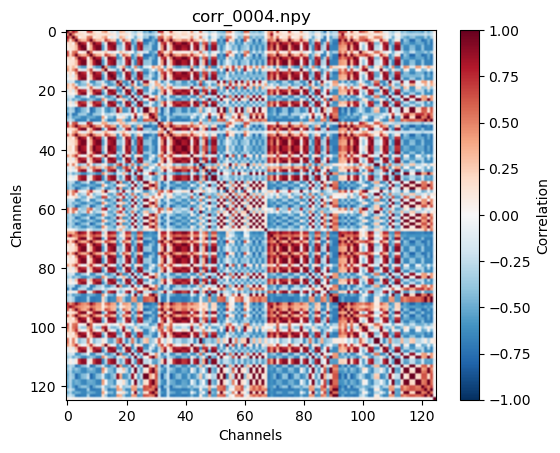

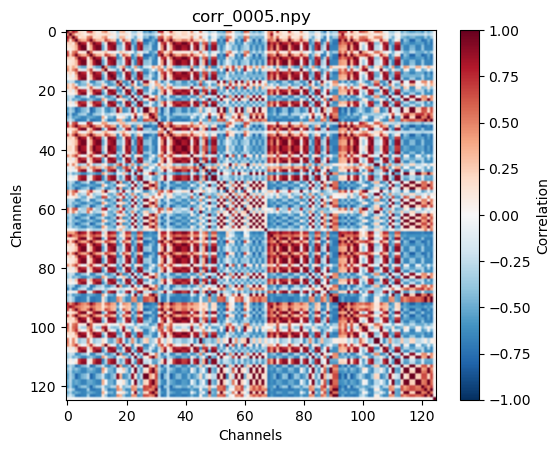

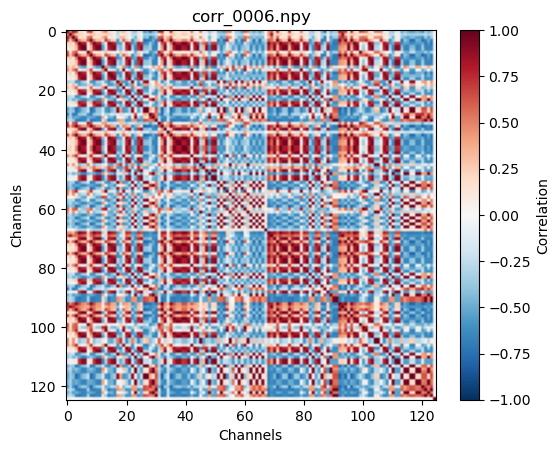

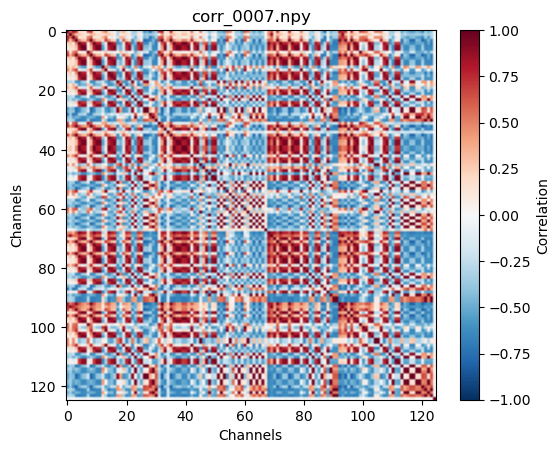

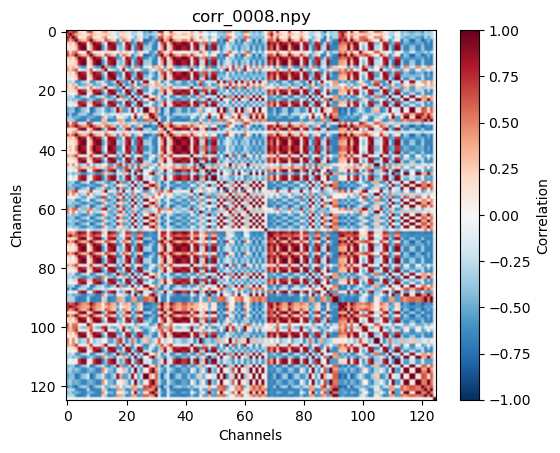

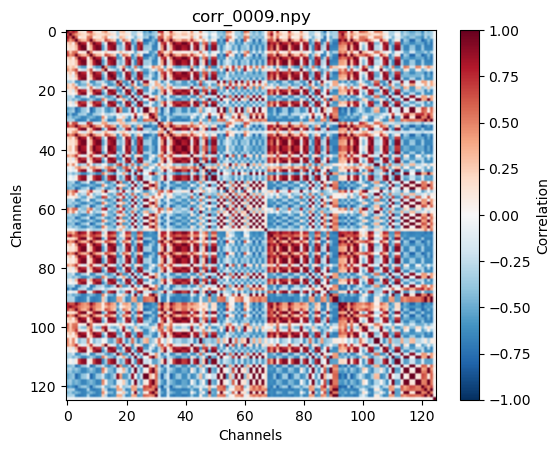

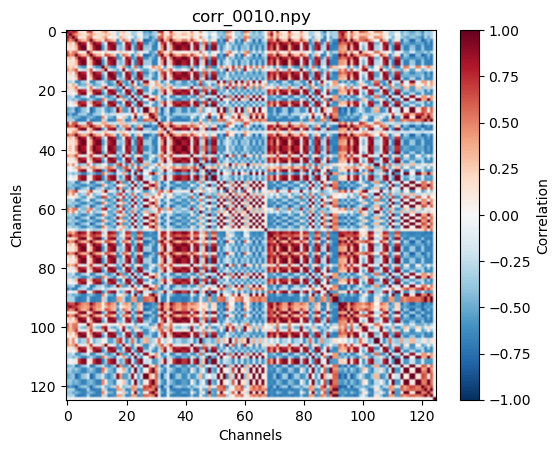

In [60]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ---- Load matrices ----
file_path_1 = os.path.join("corr_matrices", "corr_0005.npy")
file_path_2 = os.path.join("corr_matrices", "corr_0580.npy")

matrix1 = np.load(file_path_1)
matrix2 = np.load(file_path_2)

# ---- Plot side by side ----
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

im1 = ax[0].imshow(matrix1[:10, :10], vmin=-0.5, vmax=0.5, cmap='RdBu_r')
ax[0].set_title("Window 0005")
ax[0].set_xlabel("Channels")
ax[0].set_ylabel("Channels")

im2 = ax[1].imshow(matrix2[:10, :10], vmin=-0.5, vmax=0.5, cmap='RdBu_r')
ax[1].set_title("Window 0580")
ax[1].set_xlabel("Channels")
ax[1].set_ylabel("Channels")

# Single shared colorbar
fig.colorbar(im2, ax=ax, label="Correlation")

fig.suptitle("Correlation Matrix Comparison")
plt.show()


print(line)

files = sorted(
    [f for f in os.listdir("corr_matrices1") if f.endswith(".npy")]
)
maximal = 0
for f in files:
    matrixce = np.load(os.path.join("corr_matrices1", f))
    
    plt.figure()
    plt.imshow(matrixce, vmin=-1, vmax=1, cmap='RdBu_r')
    plt.colorbar(label="Correlation")
    plt.title(f"{f}")
    plt.xlabel("Channels")
    plt.ylabel("Channels")
    plt.show()
    if (maximal ==10):
        break
    maximal +=1



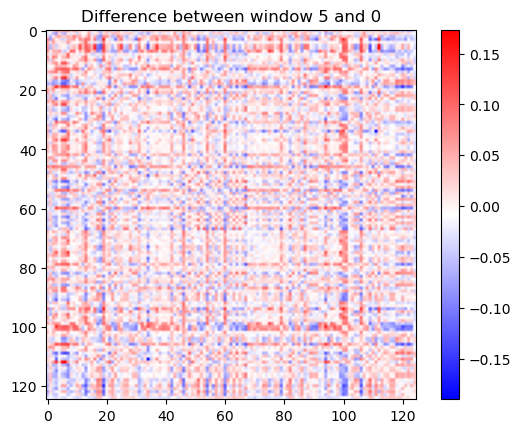

Mean absolute change: 0.032030069043333255


In [29]:
m1 = np.load(os.path.join("corr_matrices1", files[0]))
m2 = np.load(os.path.join("corr_matrices1", files[5]))

diff = m2 - m1

plt.imshow(diff, cmap='bwr')
plt.colorbar()
plt.title("Difference between window 5 and 0")
plt.show()

print("Mean absolute change:", np.abs(diff).mean())


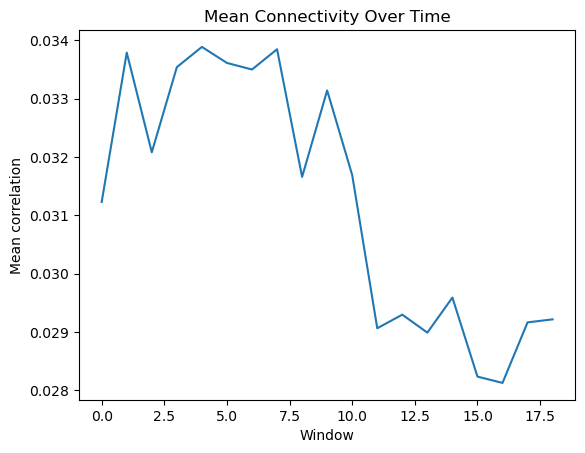

In [30]:
means = []

for f in files:
    m = np.load(os.path.join("corr_matrices1", f))
    means.append(m.mean())

plt.plot(means)
plt.title("Mean Connectivity Over Time")
plt.xlabel("Window")
plt.ylabel("Mean correlation")
plt.show()


In [44]:
První týden, os na nový počítači
a
Druhý týden, cluster pouštět na více souborech (video)

SyntaxError: invalid syntax (3995649692.py, line 1)